In [55]:
! pip install langchain-huggingface sentence-transformers

In [56]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf


In [57]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
import os

In [58]:
load_dotenv()

True

In [ ]:
llm=ChatGoogleGenerativeAI(models="gemini-flash-2.5", temperature=0.2, google_api_key=os.environ.get("GOOGLE_API_KEY_1"))

In [60]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [61]:
len(docs)

392

In [ ]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=2000)
chunks = splitter.split_documents(docs)

In [63]:
len(chunks)

387

In [64]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)
vector_store = FAISS.from_documents(chunks, embeddings)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1286.41it/s]


In [65]:
vector_store

In [66]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [67]:
@tool
def rag_tool(query: str):
    """
    Retrieve relevant information from the pdf document.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query": query,
        "context": context,
        "metadata": metadata,
    }

In [82]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [69]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [70]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [71]:
tool_node = ToolNode(tools)

In [72]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

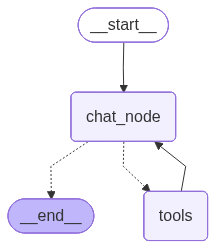

In [73]:
chatbot

In [83]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

ChatGoogleGenerativeAIError: Error calling model 'gemini-flash-2.5' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-flash-2.5 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}

In [79]:
print(result['messages'][-1].content)

TypeError: 'coroutine' object is not subscriptable